<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/PCA_vs_t_SNE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances

# 1. Generate synthetic data
# Define centers manually
centers = [
    [0, 0, 0, 0, 0],     # blob 1
    [1, 1, 1, 1, 1],     # blob 2 (close to blob 1)
    [10, 10, 10, -10, -10],     # blob 3 (far away)
    [-10, -10, -10, 10, 10]     # blob 4 (far away)
]

X, labels = make_blobs(n_samples=400, centers=centers, n_features=5, cluster_std=0.6, random_state=42)
print(X)



[[-10.79201351 -10.36706145 -10.02222208   9.74241867   9.58454741]
 [  0.31160791   0.91964335  -0.06525609   0.24102703   0.4140864 ]
 [ -0.53370866  -0.48948617  -0.04626103   0.20469118   0.16601448]
 ...
 [ -9.97383853  -8.98296938 -10.37358962  10.11676447   9.55451765]
 [  0.0147061    0.29879897   0.87068616   0.5755625    1.29190947]
 [-10.8745309  -10.18552545 -10.45129384  10.19150471  10.80427027]]


In [42]:
from sklearn.decomposition import PCA

# Apply PCA to the high-dimensional data X
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

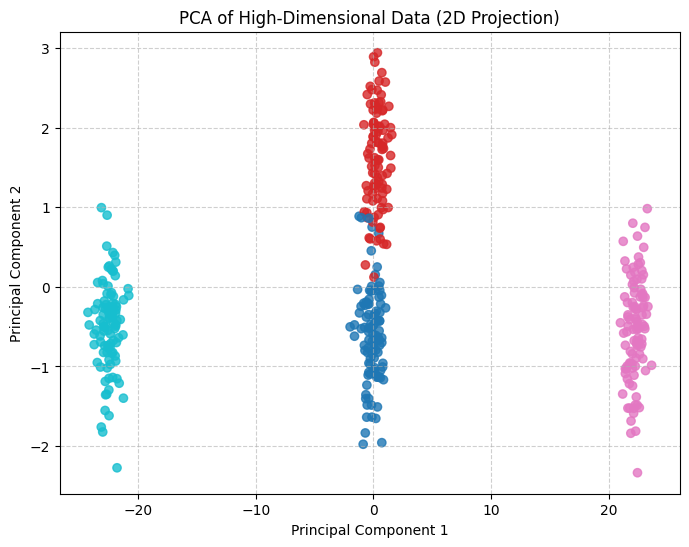

In [43]:
fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
ax_pca.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.8)
ax_pca.set_title('PCA of High-Dimensional Data (2D Projection)')
ax_pca.set_xlabel('Principal Component 1')
ax_pca.set_ylabel('Principal Component 2')
ax_pca.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [44]:
from sklearn.manifold import TSNE

# Apply t-SNE to the high-dimensional data X
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

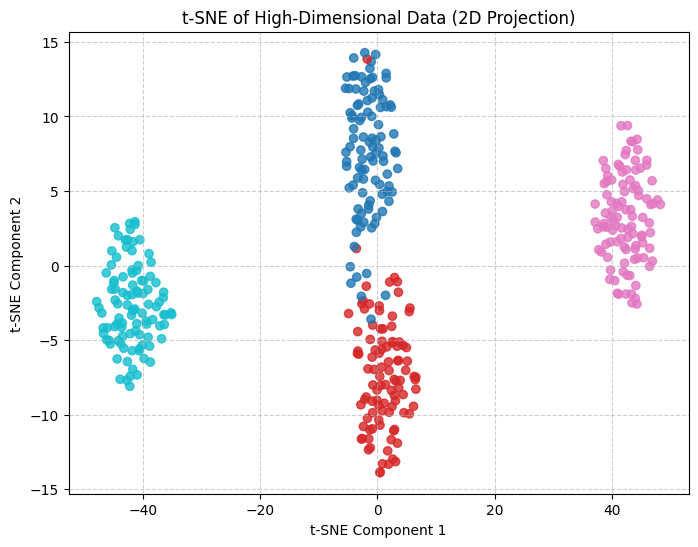

In [45]:
fig_tsne, ax_tsne = plt.subplots(figsize=(8, 6))
ax_tsne.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', alpha=0.8)
ax_tsne.set_title('t-SNE of High-Dimensional Data (2D Projection)')
ax_tsne.set_xlabel('t-SNE Component 1')
ax_tsne.set_ylabel('t-SNE Component 2')
ax_tsne.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [49]:
n_samples = X.shape[0]

high_variance_feature_1 = 20 * np.random.randn(n_samples, 1)
high_variance_feature_2 = 20 * np.random.randn(n_samples, 1)

# Concatenate the original 5 features with the 2 new high-variance features
X1 = np.concatenate((X, high_variance_feature_1, high_variance_feature_2), axis=1)

print(f"Shape of original X: {X.shape}")
print(f"Shape of new X1: {X1.shape}")
print(f"Variance of new feature 1: {np.var(high_variance_feature_1):.2f}")
print(f"Variance of new feature 2: {np.var(high_variance_feature_2):.2f}")

Shape of original X: (400, 5)
Shape of new X1: (400, 7)
Variance of new feature 1: 420.35
Variance of new feature 2: 372.76


Explained variance ratio of principal components: [0.40370257 0.34959889]


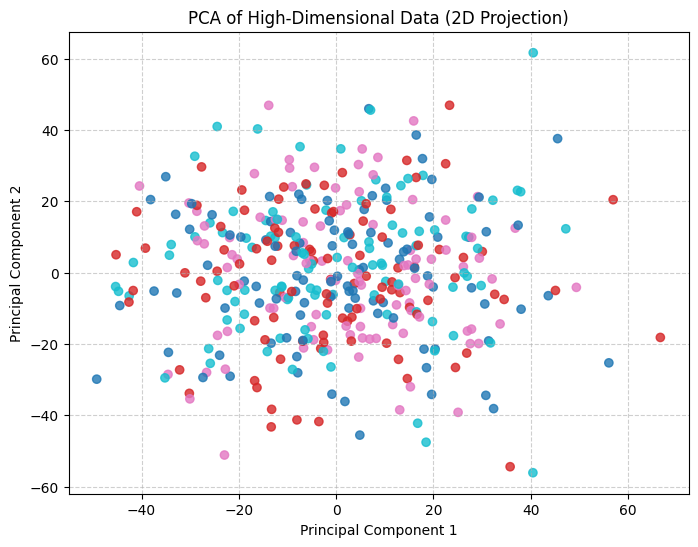

In [47]:
# Apply PCA to the high-dimensional data X
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X1)
print(f"Explained variance ratio of principal components: {pca.explained_variance_ratio_}")

fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
ax_pca.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.8)
ax_pca.set_title('PCA of High-Dimensional Data (2D Projection)')
ax_pca.set_xlabel('Principal Component 1')
ax_pca.set_ylabel('Principal Component 2')
ax_pca.grid(True, linestyle='--', alpha=0.6)
plt.show()

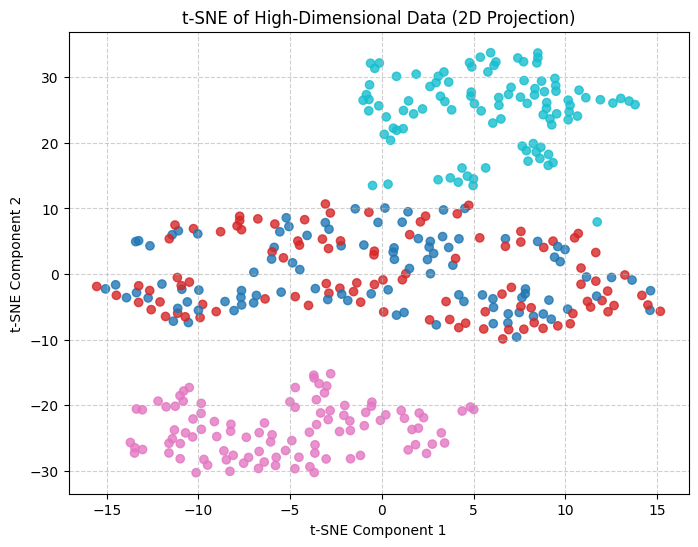

In [50]:
# Apply t-SNE to the high-dimensional data X
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X1)

fig_tsne, ax_tsne = plt.subplots(figsize=(8, 6))
ax_tsne.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', alpha=0.8)
ax_tsne.set_title('t-SNE of High-Dimensional Data (2D Projection)')
ax_tsne.set_xlabel('t-SNE Component 1')
ax_tsne.set_ylabel('t-SNE Component 2')
ax_tsne.grid(True, linestyle='--', alpha=0.6)
plt.show()